# Fine Tuning BERT for Question Answering
This notebook is a companion of chapter 2 of the "Domain Specific LLMs in Action" book, author Guglielmo Iozzia, [Manning Publications](https://www.manning.com/), 2024.
The code in this notebook is to show how to fine tune a [DistilBert](https://huggingface.co/distilbert-base-uncased-finetuned-sst-2-english) model for extractive question answering (extract the answer from a given context). While all the steps refer to DistilBert, the same apply to a larger pool of LLM architectures.   
While no hardware acceleration is required to execute all the code cells, it is recommended to use a GPU to speed up the fine tuning step.

## Settings

Install the missing requirements in the Colab VM (HF's Datasets and Accelerate).

In [ ]:
# !pip install datasets accelerate

## Data Preparation

Load a subset (5000 samples) of the *SQuAD* dataset using the HF's *Datasets* library.

In [1]:
from datasets import load_dataset

squad = load_dataset("squad", split="train[:5000]")

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/14.5M [00:00<?, ?B/s]

plain_text/validation-00000-of-00001.par(…):   0%|          | 0.00/1.82M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/87599 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10570 [00:00<?, ? examples/s]

In [5]:
squad[:2]

{'id': ['5733be284776f41900661182', '5733be284776f4190066117f'],
 'title': ['University_of_Notre_Dame', 'University_of_Notre_Dame'],
 'context': ['Architecturally, the school has a Catholic character. Atop the Main Building\'s gold dome is a golden statue of the Virgin Mary. Immediately in front of the Main Building and facing it, is a copper statue of Christ with arms upraised with the legend "Venite Ad Me Omnes". Next to the Main Building is the Basilica of the Sacred Heart. Immediately behind the basilica is the Grotto, a Marian place of prayer and reflection. It is a replica of the grotto at Lourdes, France where the Virgin Mary reputedly appeared to Saint Bernadette Soubirous in 1858. At the end of the main drive (and in a direct line that connects through 3 statues and the Gold Dome), is a simple, modern stone statue of Mary.',
  'Architecturally, the school has a Catholic character. Atop the Main Building\'s gold dome is a golden statue of the Virgin Mary. Immediately in front o

Split the dataset's `train` split into a train and test set (80%/20%) with the *train_test_split* method:

In [6]:
squad = squad.train_test_split(test_size=0.2)

Display a sample:

In [7]:
squad["train"][0]

{'id': '56d133a017492d1400aabc1d',
 'title': 'To_Kill_a_Mockingbird',
 'context': 'The strongest element of style noted by critics and reviewers is Lee\'s talent for narration, which in an early review in Time was called "tactile brilliance". Writing a decade later, another scholar noted, "Harper Lee has a remarkable gift of story-telling. Her art is visual, and with cinematographic fluidity and subtlety we see a scene melting into another scene without jolts of transition." Lee combines the narrator\'s voice of a child observing her surroundings with a grown woman\'s reflecting on her childhood, using the ambiguity of this voice combined with the narrative technique of flashback to play intricately with perspectives. This narrative method allows Lee to tell a "delightfully deceptive" story that mixes the simplicity of childhood observation with adult situations complicated by hidden motivations and unquestioned tradition. However, at times the blending causes reviewers to question Sco

The three important fields are:

- `answers`: the starting location of the answer token and the answer text.
- `context`: background information from which the model needs to extract the answer.
- `question`: the question a model should answer.

Load a DistilBERT tokenizer to process the `question` and `context` fields in the training set.

In [8]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Some data preprocessing is needed:

1. Some examples in a dataset may have a very long `context` that exceeds the maximum input length of the model. To deal with longer sequences, truncate only the `context` by setting `truncation="only_second"`.
2. Map the start and end positions of the answer to the original `context` by setting
   `return_offset_mapping=True`.
3. Use the *sequence_ids* method to
   find which part of the offset corresponds to the `question` and which corresponds to the `context`.

Let's define a function that implementes the aforementioned preprocessing steps:

In [9]:
def preprocess_function(examples):
    questions = [q.strip() for q in examples["question"]]
    inputs = tokenizer(
        questions,
        examples["context"],
        max_length=384,
        truncation="only_second",
        return_offsets_mapping=True,
        padding="max_length",
    )

    offset_mapping = inputs.pop("offset_mapping")
    answers = examples["answers"]
    start_positions = []
    end_positions = []

    for i, offset in enumerate(offset_mapping):
        answer = answers[i]
        start_char = answer["answer_start"][0]
        end_char = answer["answer_start"][0] + len(answer["text"][0])
        sequence_ids = inputs.sequence_ids(i)

        # Find the start and end of the context
        idx = 0
        while sequence_ids[idx] != 1:
            idx += 1
        context_start = idx
        while sequence_ids[idx] == 1:
            idx += 1
        context_end = idx - 1

        # If the answer is not fully inside the context, label it (0, 0)
        if offset[context_start][0] > end_char or offset[context_end][1] < start_char:
            start_positions.append(0)
            end_positions.append(0)
        else:
            # Otherwise it's the start and end token positions
            idx = context_start
            while idx <= context_end and offset[idx][0] <= start_char:
                idx += 1
            start_positions.append(idx - 1)

            idx = context_end
            while idx >= context_start and offset[idx][1] >= end_char:
                idx -= 1
            end_positions.append(idx + 1)

    inputs["start_positions"] = start_positions
    inputs["end_positions"] = end_positions
    return inputs

To apply the preprocessing function over the entire dataset, we can use the HF's Datasets *map* function. By setting `batched=True`, multiple elements of the dataset will be processed at once.

In [10]:
tokenized_squad = squad.map(preprocess_function, batched=True, remove_columns=squad["train"].column_names)

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Now create a batch of examples using DefaultDataCollator. Unlike other data collators in the HF's Transformers library, it doesn't apply any additional preprocessing.

In [11]:
from transformers import DefaultDataCollator

data_collator = DefaultDataCollator()

## Fine Tuning

Load DistilBERT with *AutoModelForQuestionAnswering*:

In [12]:
from transformers import AutoModelForQuestionAnswering, TrainingArguments, Trainer

model = AutoModelForQuestionAnswering.from_pretrained("distilbert-base-uncased",
                                                    device_map="auto")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForQuestionAnswering were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['qa_outputs.bias', 'qa_outputs.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Define the training hyperparameters in a *TrainingArguments* instance. The only required parameter is *output_dir* which specifies where to save our model.

In [13]:
training_args = TrainingArguments(
    output_dir="my_awesome_qa_model",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    push_to_hub=False,
    report_to="none",
)

Pass the training arguments to a *Trainer* instance along with the model, the dataset, the tokenizer, and the data collator.

In [14]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_squad["train"],
    eval_dataset=tokenized_squad["test"],
    processing_class=tokenizer,
    data_collator=data_collator,
)

The model is already on multiple devices. Skipping the move to device specified in `args`.


Start the fine tuning:

In [15]:
trainer.train()

/Users/johnmachado/Desktop/Domain-Specific-Small-Language-Models/env/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss
1,No log,2.281843
2,2.749100,1.676290
3,2.749100,1.594775


/Users/johnmachado/Desktop/Domain-Specific-Small-Language-Models/env/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/johnmachado/Desktop/Domain-Specific-Small-Language-Models/env/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


TrainOutput(global_step=750, training_loss=2.3033250732421875, metrics={'train_runtime': 588.776, 'train_samples_per_second': 20.381, 'train_steps_per_second': 1.274, 'total_flos': 1175877900288000.0, 'train_loss': 2.3033250732421875, 'epoch': 3.0})

## Inference

The finetuned model can now be used for inference. Let's provide a question and some context we'd like the model to predict:

In [24]:
question = "How many official league titles has Juventus won?"
context = "Juventus Football Club (from Latin: iuventūs), colloquially known as Juve, is a professional football club based in Turin, Piedmont, Italy, that competes in the Serie A, the top tier of the Italian football league system. Founded in 1897 by a group of Torinese students, the club has worn a black and white striped home kit since 1903 and has played home matches in different grounds around its city, the latest being the 41,507-capacity Juventus Stadium. Nicknamed la Vecchia Signora (the Old Lady), the club has won 36 official league titles, 14 Coppa Italia titles and nine Supercoppa Italiana titles, being the record holder for all these competitions;"

First, tokenize the text and return PyTorch tensors:

In [25]:
import torch
from transformers import AutoTokenizer

# device = "cuda" if torch.cuda.is_available() else "cpu"

# If on Mac
device = "mps" 

inputs = tokenizer(question, context, return_tensors="pt")
inputs.to(device)

{'input_ids': tensor([[  101,  2129,  2116,  2880,  2223,  4486,  2038, 22760,  2180,  1029,
           102, 22760,  2374,  2252,  1006,  2013,  3763,  1024,  1045, 27346,
          5809,  1007,  1010, 23992,  2124,  2004, 18414,  3726,  1010,  2003,
          1037,  2658,  2374,  2252,  2241,  1999, 13667,  1010, 18873,  1010,
          3304,  1010,  2008, 14190,  1999,  1996,  8668,  1037,  1010,  1996,
          2327,  7563,  1997,  1996,  3059,  2374,  2223,  2291,  1012,  2631,
          1999,  6347,  2011,  1037,  2177,  1997, 23413, 14183,  2493,  1010,
          1996,  2252,  2038,  6247,  1037,  2304,  1998,  2317, 17983,  2188,
          8934,  2144,  5778,  1998,  2038,  2209,  2188,  3503,  1999,  2367,
          5286,  2105,  2049,  2103,  1010,  1996,  6745,  2108,  1996,  4601,
          1010,  2753,  2581,  1011,  3977, 22760,  3346,  1012,  9919,  2474,
          2310, 25955,  2050,  3696,  6525,  1006,  1996,  2214,  3203,  1007,
          1010,  1996,  2252,  2038,  

Then let's pass our inputs to the model and return the `logits`:

In [26]:
from transformers import AutoModelForQuestionAnswering

with torch.no_grad():
    outputs = model(**inputs)

Get the highest probability from the model output for the start and end positions:

In [27]:
answer_start_index = outputs.start_logits.argmax()
answer_end_index = outputs.end_logits.argmax()

Decode the predicted tokens to get the answer in natural language:

In [28]:
predict_answer_tokens = inputs.input_ids[0, answer_start_index : answer_end_index + 1]
tokenizer.decode(predict_answer_tokens)

'36'

## Loading the trained model from Hugging Face

In [42]:
tokenizer = AutoTokenizer.from_pretrained("John-Machado/distilbert-squad-qa")
model = AutoModelForQuestionAnswering.from_pretrained("John-Machado/distilbert-squad-qa")

In [43]:
model

DistilBertForQuestionAnswering(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
     

In [51]:
import matplotlib.pyplot as plt
import torch.nn.functional as F

def visualize_qa(question, context, model, tokenizer):
    inputs = tokenizer(question, context, return_tensors="pt")
    with torch.no_grad():
        outputs = model(**inputs)

    tokens = tokenizer.convert_ids_to_tokens(inputs.input_ids[0])
    start_probs = F.softmax(outputs.start_logits[0], dim=-1).detach().cpu()
    end_probs = F.softmax(outputs.end_logits[0], dim=-1).detach().cpu()

    start_idx = outputs.start_logits.argmax().item()
    end_idx = outputs.end_logits.argmax().item()
    answer = tokenizer.decode(inputs.input_ids[0, start_idx : end_idx + 1])

    # Print summary
    print(f"Question:  {question}")
    print(f"Context:   {context}")
    print(f"Answer:    \"{answer}\"")
    print(f"Span:      tokens[{start_idx}] to tokens[{end_idx}]")
    print()

    # Top 10 tokens by start/end probability
    top_start = start_probs.topk(10)
    top_end = end_probs.topk(10)

    print(f"{'Token':<20} {'Start Prob':>12}    {'Token':<20} {'End Prob':>12}")
    print(f"{'-'*20} {'-'*12}    {'-'*20} {'-'*12}")
    for i in range(10):
        s_tok = tokens[top_start.indices[i]]
        s_prob = top_start.values[i].item()
        e_tok = tokens[top_end.indices[i]]
        e_prob = top_end.values[i].item()
        s_marker = " <--" if top_start.indices[i] == start_idx else ""
        e_marker = " <--" if top_end.indices[i] == end_idx else ""
        print(f"{s_tok:<20} {s_prob:>11.4f}{s_marker}    {e_tok:<20} {e_prob:>11.4f}{e_marker}")

    # Bar charts
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 8), sharex=True)

    start_np = start_probs.numpy()
    end_np = end_probs.numpy()

    bars1 = ax1.bar(range(len(tokens)), start_np, color="steelblue", alpha=0.7)
    bars1[start_idx].set_color("red")
    bars1[start_idx].set_alpha(1.0)
    ax1.set_ylabel("Probability")
    ax1.set_title(f"Start Logits — predicted start: '{tokens[start_idx]}' (index {start_idx})")

    bars2 = ax2.bar(range(len(tokens)), end_np, color="steelblue", alpha=0.7)
    bars2[end_idx].set_color("red")
    bars2[end_idx].set_alpha(1.0)
    ax2.set_ylabel("Probability")
    ax2.set_title(f"End Logits — predicted end: '{tokens[end_idx]}' (index {end_idx})")

    ax2.set_xticks(range(len(tokens)))
    ax2.set_xticklabels(tokens, rotation=90, fontsize=6)
    ax2.set_xlabel("Tokens")

    fig.suptitle(f"Predicted Answer: \"{answer}\"", fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

Question:  When was the Berlin Wall torn down?
Context:   The Berlin Wall was a guarded concrete barrier that physically and ideologically divided Berlin from 1961 to 1989. Its demolition officially began on 13 June 1990 and was completed in November 1991. The fall of the Berlin Wall on 9 November 1989 was a pivotal event in world history which marked the falling of the Iron Curtain.
Answer:    "13 june 1990 and was completed in november 1991. the fall of the berlin wall on 9 november 1989"
Span:      tokens[35] to tokens[54]

Token                  Start Prob    Token                    End Prob
-------------------- ------------    -------------------- ------------
13                        0.2020 <--    1989                      0.3948 <--
9                         0.1754    1991                      0.2285
november                  0.1692    1989                      0.1881
1961                      0.1215    1990                      0.1339
the                       0.0713    1961 

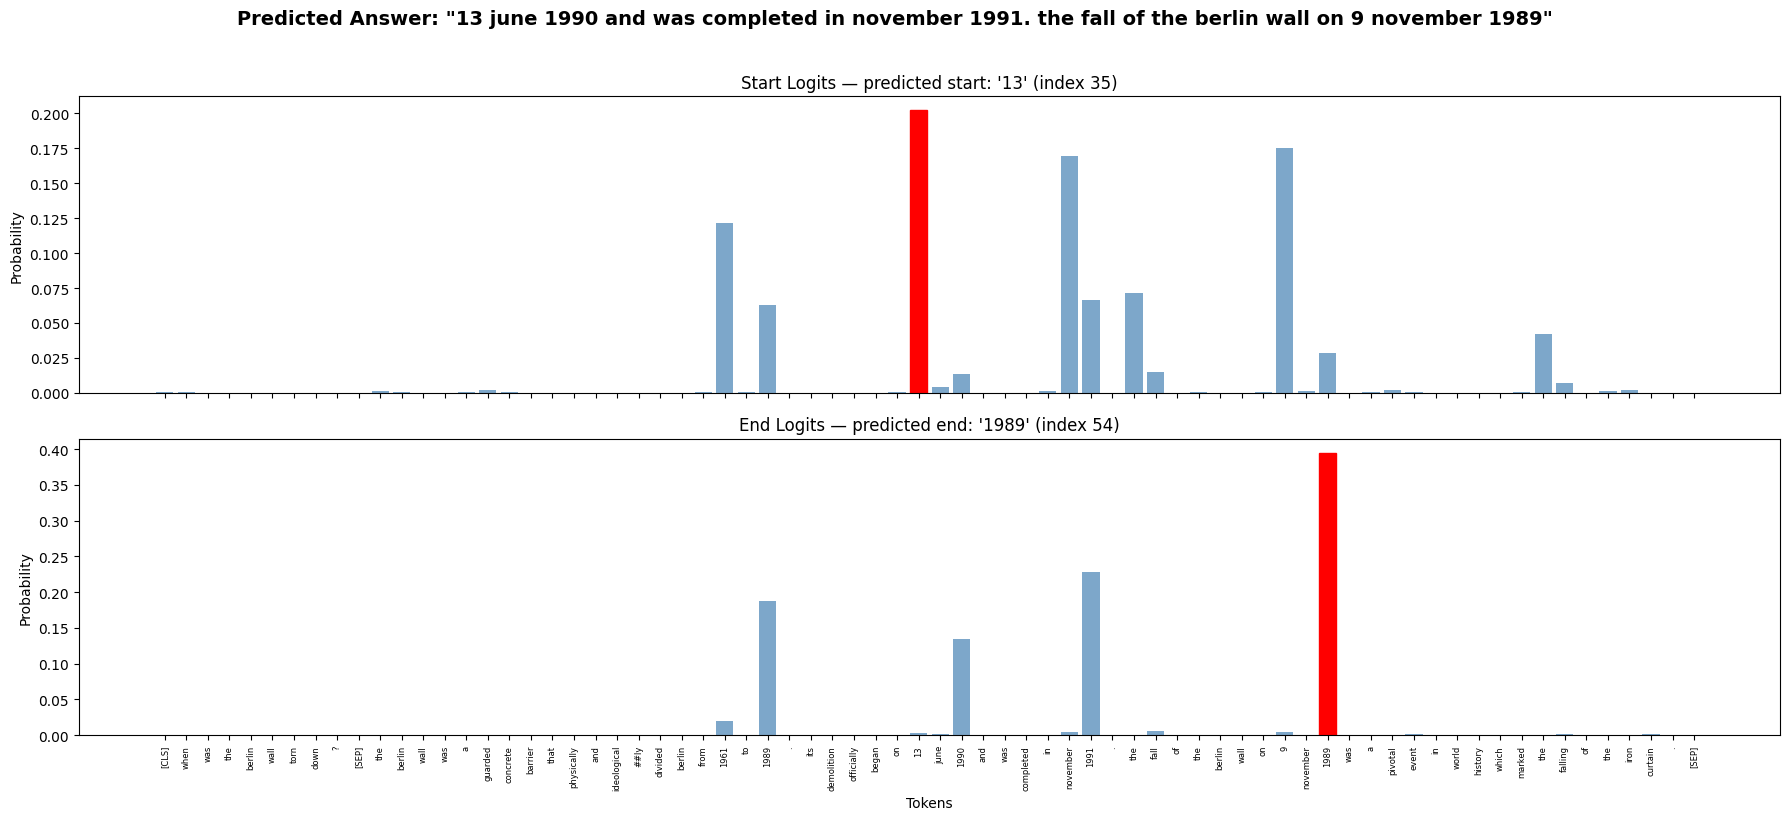

In [52]:
visualize_qa(
    "When was the Berlin Wall torn down?",
    "The Berlin Wall was a guarded concrete barrier that physically and ideologically divided Berlin from 1961 to 1989. Its demolition officially began on 13 June 1990 and was completed in November 1991. The fall of the Berlin Wall on 9 November 1989 was a pivotal event in world history which marked the falling of the Iron Curtain.",
    model, tokenizer
)

Question:  When was the Berlin Wall torn down?
Context:   The Berlin Wall was a guarded concrete barrier that physically and ideologically divided Berlin from 1961 to 1989. Its demolition officially began on 13 June 1990 and was completed in November 1991. The fall of the Berlin Wall on 9 November 1989 was a pivotal event in world history which marked the falling of the Iron Curtain.
Answer:    "13 june 1990 and was completed in november 1991. the fall of the berlin wall on 9 november 1989"
Span:      tokens[35] to tokens[54]

Token                  Start Prob    Token                    End Prob
-------------------- ------------    -------------------- ------------
13                        0.2020 <--    1989                      0.3948 <--
9                         0.1754    1991                      0.2285
november                  0.1692    1989                      0.1881
1961                      0.1215    1990                      0.1339
the                       0.0713    1961 

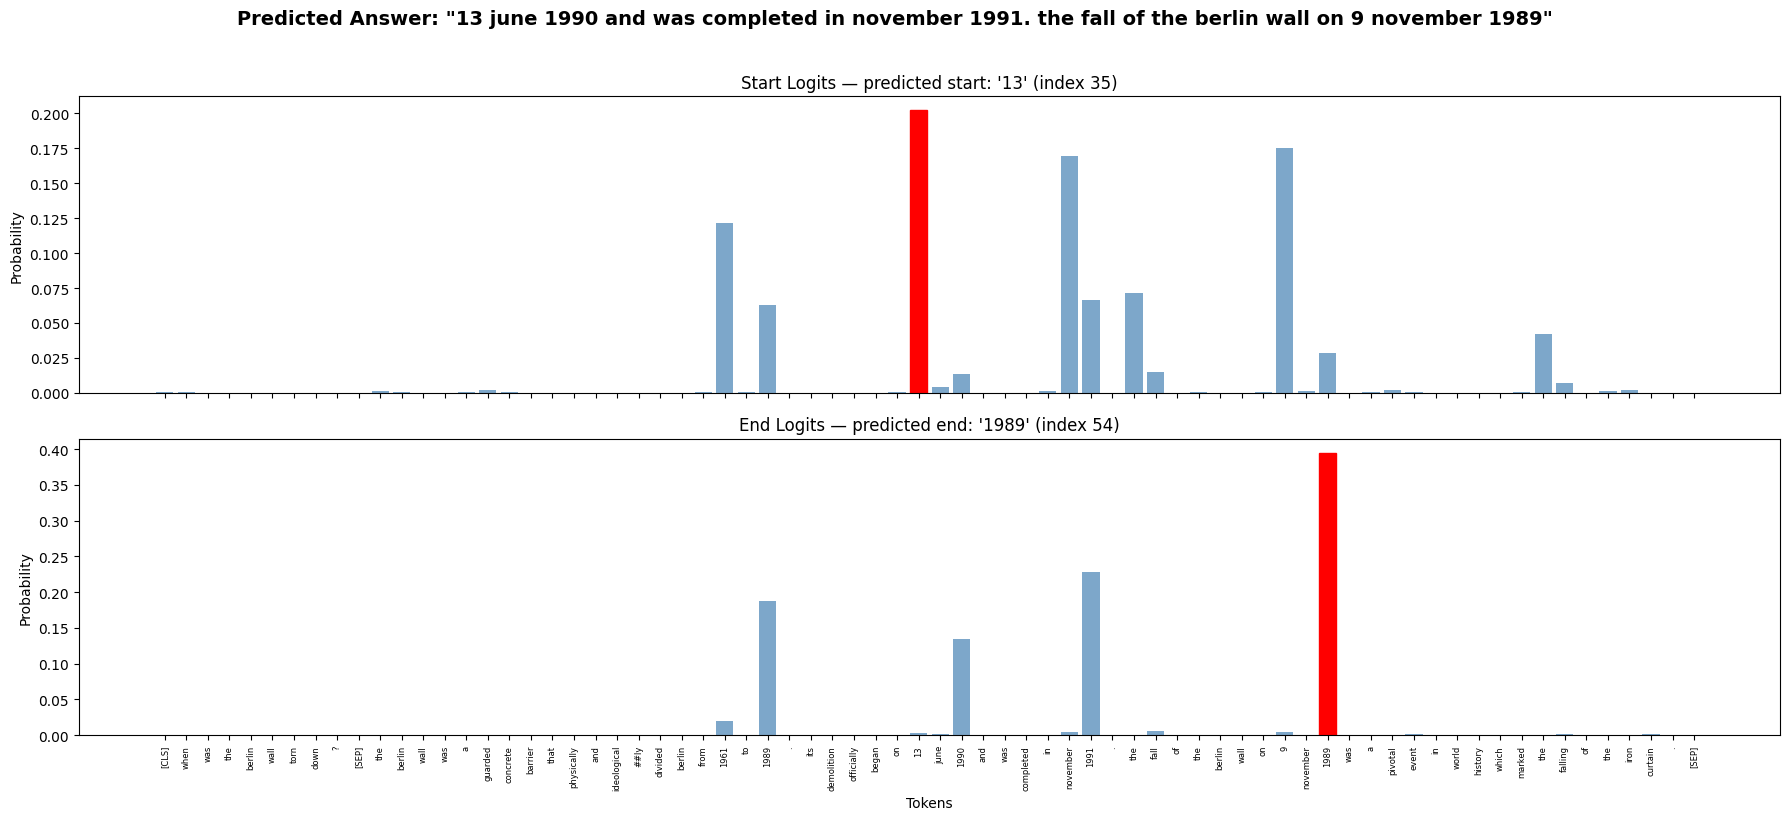

In [53]:
# Question + Context
visualize_qa(
    "When was the Berlin Wall torn down?",
    "The Berlin Wall was a guarded concrete barrier that physically and ideologically divided Berlin from 1961 to 1989. Its demolition officially began on 13 June 1990 and was completed in November 1991. The fall of the Berlin Wall on 9 November 1989 was a pivotal event in world history which marked the falling of the Iron Curtain.",
    model, tokenizer
)

Question:  What year was the Eiffel Tower completed?
Context:   The Eiffel Tower is a wrought-iron lattice tower on the Champ de Mars in Paris, France. It is named after the engineer Gustave Eiffel, whose company designed and built the tower from 1887 to 1889. Locally nicknamed La dame de fer, it was constructed as the centerpiece of the 1889 World's Fair and to demonstrate France's industrial prowess. The tower is 330 metres tall and was the world's tallest man-made structure until the Chrysler Building in New York City was topped out in 1929.
Answer:    "1889"
Span:      tokens[74] to tokens[74]

Token                  Start Prob    Token                    End Prob
-------------------- ------------    -------------------- ------------
1889                      0.7943 <--    1889                      0.3747 <--
1929                      0.0672    1889                      0.3043
1889                      0.0593    1929                      0.2277
1887                      0.0588    1

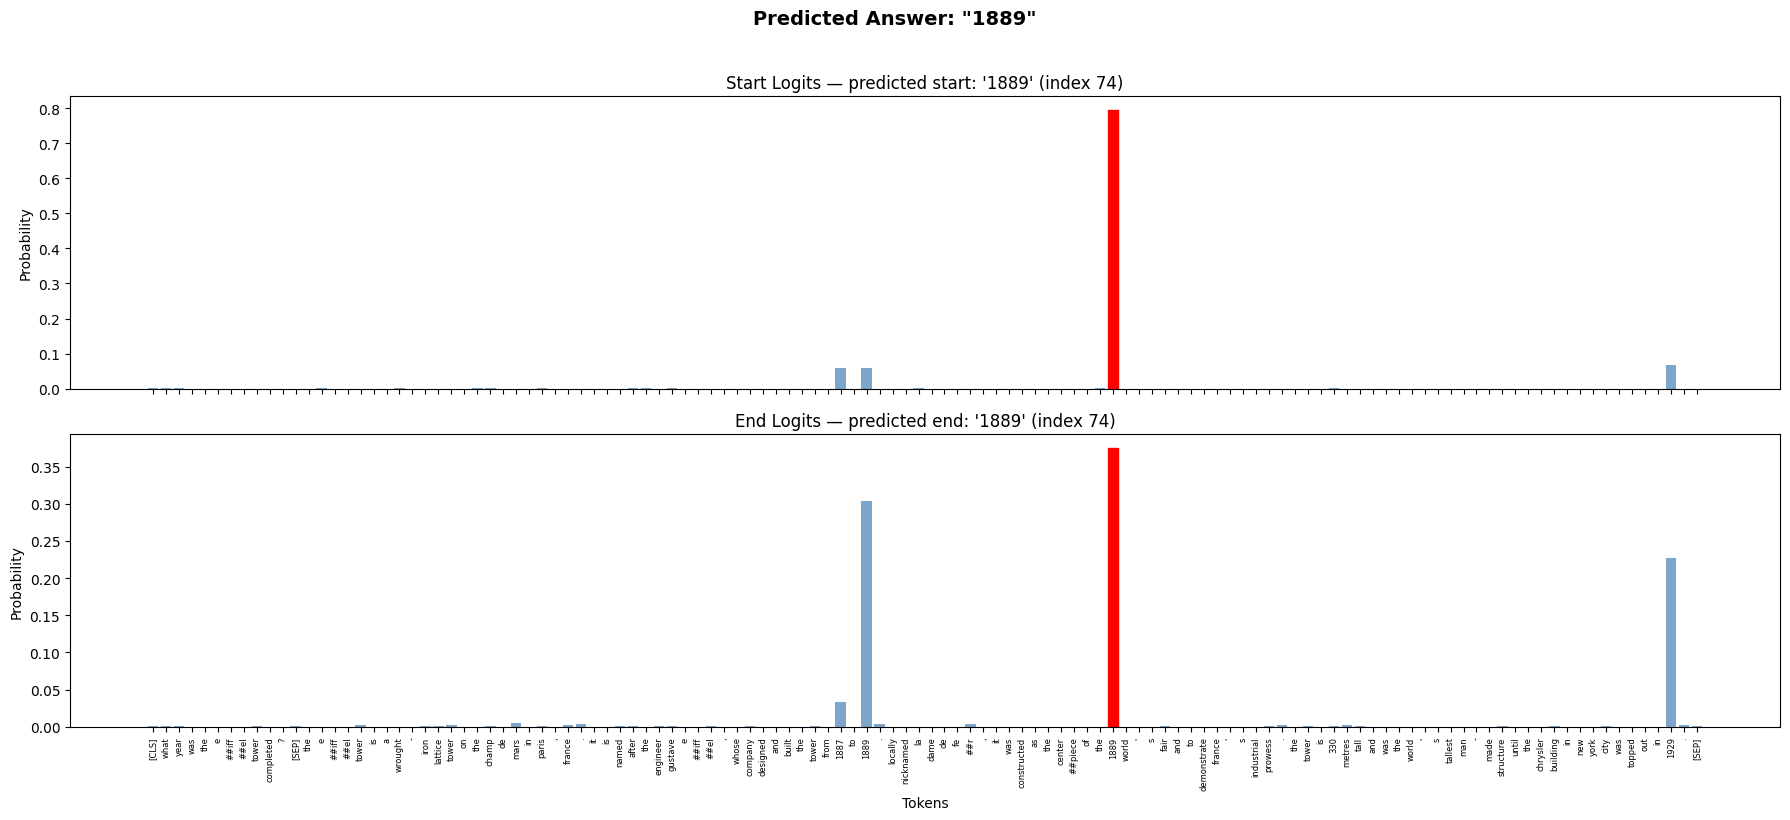

In [54]:
# Question + Context
visualize_qa(
    "What year was the Eiffel Tower completed?",
    "The Eiffel Tower is a wrought-iron lattice tower on the Champ de Mars in Paris, France. It is named after the engineer Gustave Eiffel, whose company designed and built the tower from 1887 to 1889. Locally nicknamed La dame de fer, it was constructed as the centerpiece of the 1889 World's Fair and to demonstrate France's industrial prowess. The tower is 330 metres tall and was the world's tallest man-made structure until the Chrysler Building in New York City was topped out in 1929.",
    model, tokenizer
)